## Task: Predict medical billing charges based on customer demographic data.

Business Logic: Identify cases where the actual billed amount is a massive statistical outlier (>3 standard deviations) above the model's predicted cost, flagging potential overcharging or waste.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error
from scipy.stats import zscore

df=pd.read_csv('/kaggle/input/datasets/attilisaisreetanvi/medicalcost/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/attilisaisreetanvi
/kaggle/input/datasets/attilisaisreetanvi/medicalcost
    insurance.csv
/kaggle/input/notebooks
/kaggle/input/notebooks/rafetcan
/kaggle/input/notebooks/mragpavank
/kaggle/input/notebooks/mragpavank/medical-cost-personal-datasets
    __results__.html
    __resultx__.html
    __notebook__.ipynb
    __output__.json
    custom.css


## Preprocessing

In [12]:
data=df.copy()
data['sex']=LabelEncoder().fit_transform(data['sex'])
data['smoker']=(data['smoker']=='yes').astype(int)
data=pd.get_dummies(data,columns=['region'],drop_first=True)
data['age_squared']=data['age']**2
data['bmi_smoker']=data['bmi']*data['smoker']
X=data.drop(columns='charges')
y=data['charges']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Model

In [13]:
model=GradientBoostingRegressor(random_state=42)
model.fit(X_train,y_train)
pred=model.predict(X_test)
print(r2_score(y_test,pred),mean_absolute_error(y_test,pred))
data['predicted_charges']=model.predict(X)
data['residual']=data['charges']-data['predicted_charges']
data['zscore']=zscore(data['residual'])
flagged=data[data['zscore']>3]
flagged.head()

0.8795293091533231 2451.758247274604


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,age_squared,bmi_smoker,predicted_charges,residual,zscore
3,33,1,22.705,0,0,21984.47061,True,False,False,1089,0.000,6585.243183,15399.227427,3.958116
9,60,0,25.840,0,0,28923.13692,True,False,False,3600,0.000,14371.534951,14551.601969,3.740978
102,18,0,30.115,0,0,21344.84670,False,False,False,324,0.000,3803.252108,17541.594592,4.506931
115,60,1,28.595,0,0,30259.99556,False,False,False,3600,0.000,13390.559613,16869.435947,4.334743
128,32,0,17.765,2,1,32734.18630,True,False,False,1024,17.765,14772.034156,17962.152144,4.614667


## Visualization

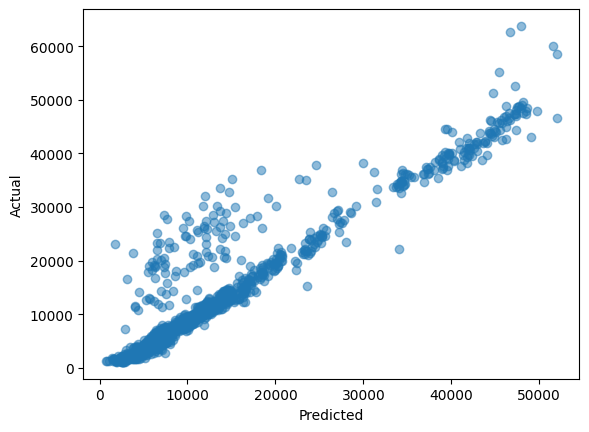

In [14]:
plt.scatter(data['predicted_charges'],data['charges'],alpha=0.5)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- Label encoding for binary features.
- One-hot encoding for region.
- Gradient Boosting for nonlinear patterns.
- Fixed random state for reproducibility.
